<a href="https://colab.research.google.com/github/Aymon05/Deep-learning-projects/blob/main/TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning
Using an existing model's architecture and learned patterns for our own problem

# Import Libraries

In [ ]:
import zipfile
import os
import tensorflow as tf

In [ ]:
# Import requirdment
import tensorflow_hub as hub
from tensorflow.keras import layers
import tf_keras as keras

# Load data

In [ ]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

--2026-09-02 16:18:51--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 34.144.170.27, 34.153.2.27, 104.154.125.27, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|34.144.170.27|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M   123MB/s    in 1.3s    

2026-09-02 16:18:52 (123 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



In [ ]:
zip_ref = zipfile.ZipFile('/content/10_food_classes_10_percent.zip')
zip_ref.extractall()
zip_ref.close()

In [ ]:
# See how many images in each folder in training
len(os.listdir('/content/10_food_classes_10_percent/train/chicken_curry'))

75

In [ ]:
# How many in test data
len(os.listdir('/content/10_food_classes_10_percent/test/chicken_curry'))

250

# Creating data loaders

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = '/content/10_food_classes_10_percent/train'
test_dir = '/content/10_food_classes_10_percent/test'

IMAGE_SHAPE = (224,224)
BATCH_SIZE = 32
EPOCHS = 5

train_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

print('Training images')
train_data = train_datagen.flow_from_directory(train_dir,batch_size = BATCH_SIZE,target_size = IMAGE_SHAPE,class_mode = 'categorical')
print('Test data')
test_data = test_datagen.flow_from_directory(test_dir,batch_size = BATCH_SIZE,target_size = IMAGE_SHAPE,class_mode = 'categorical')


Training images
Found 750 images belonging to 10 classes.
Test data
Found 2500 images belonging to 10 classes.


# Settin up callback
It runs when model is training. Callback is extra functionality connected to model which is performed during or after training.

* Tracking experiment with tensorboard callback
* Model checkpoint with the model checkpoint callback
* Stopping a model from training (Prevent **Overfitting**) with EarlyStopping callback

In [ ]:
import datetime

def create_tensorboard_callback(dir_name,experiment_name):     # Saves at that directory
    log_dir = dir_name + experiment_name + datetime.datetime.now().strftime('%d%m%Y-%H%M%S')
    tensorboard_callback = keras.callbacks.TensorBoard(log_dir = log_dir)
    print(f"Saving TensorBoard log files in : {log_dir}")
    return tensorboard_callback

The feature vector model for transfer learning from TensorflowHub :
https://www.kaggle.com/models/tensorflow/efficientnet

In [ ]:
!pip install tf_keras

In [ ]:
efficient_net_url = 'https://www.kaggle.com/models/tensorflow/efficientnet/TensorFlow2/b0-classification/1'

In [ ]:
def create_model(model_url, classes=10):
    model = keras.Sequential([
        keras.layers.InputLayer(input_shape=IMAGE_SHAPE + (3,)),
        hub.KerasLayer(model_url, trainable=False, name='Feature_extraction_layer'),
        keras.layers.Dense(classes, activation='softmax', name='Output_layer')
    ])
    return model

In [ ]:
# Creating Efficient_net model
EF_model = create_model(efficient_net_url)

In [ ]:
EF_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Feature_extraction_layer (  (None, 1000)              5330564   
 KerasLayer)                                                     
                                                                 
 Output_layer (Dense)        (None, 10)                10010     
                                                                 
Total params: 5340574 (20.37 MB)
Trainable params: 10010 (39.10 KB)
Non-trainable params: 5330564 (20.33 MB)
_________________________________________________________________


In [ ]:
EF_model.compile(loss = keras.losses.CategoricalCrossentropy(),
                 optimizer = keras.optimizers.Adam(),
                 metrics = ['accuracy'])

In [ ]:
# FIt the model
EF_history = EF_model.fit(train_data,epochs = EPOCHS,steps_per_epoch=len(train_data),validation_data = test_data,
                          validation_steps = len(test_data),callbacks = [create_tensorboard_callback(dir_name='tensorflow_hub',experiment_name='EfficientNet-B7')])

Saving TensorBoard log files in : tensorflow_hubEfficientNet-B702092026-161931
Epoch 1/5
24/24 [==============================] - 295s 12s/step - loss: 2.2926 - accuracy: 0.2120 - val_loss: 2.2830 - val_accuracy: 0.3184
Epoch 2/5
24/24 [==============================] - 317s 14s/step - loss: 2.2776 - accuracy: 0.3387 - val_loss: 2.2684 - val_accuracy: 0.3904
Epoch 3/5
24/24 [==============================] - 339s 15s/step - loss: 2.2634 - accuracy: 0.4320 - val_loss: 2.2540 - val_accuracy: 0.4900
Epoch 4/5
24/24 [==============================] - 316s 14s/step - loss: 2.2493 - accuracy: 0.5067 - val_loss: 2.2387 - val_accuracy: 0.5332
Epoch 5/5
24/24 [==============================] - 264s 11s/step - loss: 2.2349 - accuracy: 0.5560 - val_loss: 2.2240 - val_accuracy: 0.5736


# Plot loss curve

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
def plot_loss(history):
    accuracy = history.history['accuracy']
    test_accuracy = history.history['val_accuracy']
    loss = history.history['loss']
    test_loss = history.history['val_loss']
    epochs = range(len(accuracy))
    plt.figure()
    plt.subplot(1,2,1)
    plt.plot(epochs,accuracy,label = 'Train')
    plt.plot(epochs,test_accuracy,label = 'Test')
    plt.legend()
    plt.title('Accuracy')
    plt.subplot(1,2,2)
    plt.plot(epochs,loss,label = 'Train')
    plt.plot(epochs,test_loss,label = 'Test')
    plt.legend()
    plt.title('Loss')


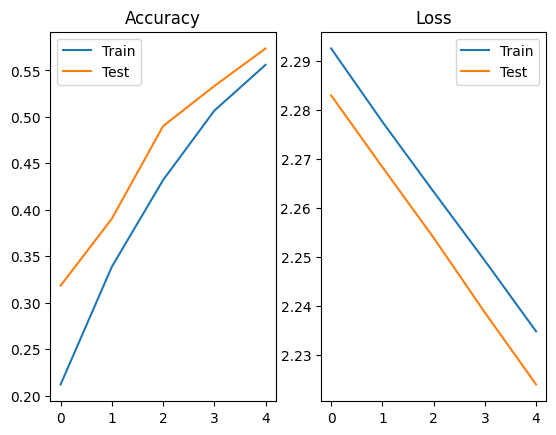

In [ ]:
plot_loss(EF_history)

# The resnet model
from Tensorflowhub ⁉
https://www.kaggle.com/models/tensorflow/resnet-50

In [ ]:
resnet_url = 'https://www.kaggle.com/models/tensorflow/resnet-50/TensorFlow2/classification/1'

In [ ]:
ResNet_model = create_model(resnet_url)

ResNet_model.compile(loss = keras.losses.CategoricalCrossentropy(),
                     optimizer = keras.optimizers.Adam(),
                     metrics = ['accuracy'])

In [ ]:
rt_history = ResNet_model.fit(train_data,epochs = 5,steps_per_epoch = len(train_data),
                              validation_data = test_data,validation_steps = len(test_data),
                              callbacks = [create_tensorboard_callback('tensorflow_hub','resnet')])

Saving TensorBoard log files in : tensorflow_hubresnet02092026-165409
Epoch 1/5
24/24 [==============================] - 717s 31s/step - loss: 2.2764 - accuracy: 0.3293 - val_loss: 2.2651 - val_accuracy: 0.3604
Epoch 2/5
24/24 [==============================] - 687s 30s/step - loss: 2.2601 - accuracy: 0.4253 - val_loss: 2.2494 - val_accuracy: 0.4612
Epoch 3/5
24/24 [==============================] - 731s 32s/step - loss: 2.2439 - accuracy: 0.5067 - val_loss: 2.2329 - val_accuracy: 0.5180
Epoch 4/5
24/24 [==============================] - 691s 30s/step - loss: 2.2290 - accuracy: 0.5560 - val_loss: 2.2156 - val_accuracy: 0.5652
Epoch 5/5
24/24 [==============================] - 725s 31s/step - loss: 2.2100 - accuracy: 0.5840 - val_loss: 2.2002 - val_accuracy: 0.5936


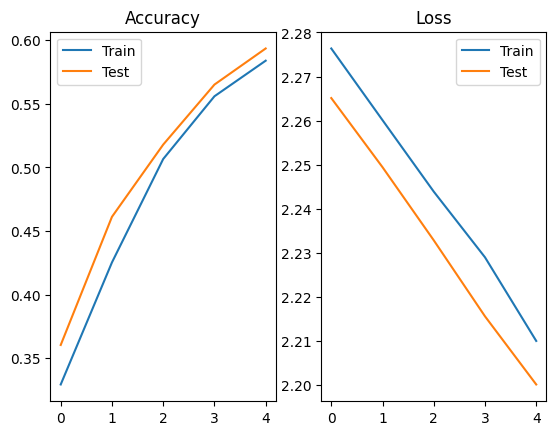

In [ ]:
plot_loss(rt_history)

In [ ]:
%cd /content

/content


# Different types of transfer learning

* "As it is" : Use an existing worked model without changing anything(Using ImageNet model on 1000classes.).
* "Feature extraction" : Using prelearned patterns of an existing model(Using ImageNet model for only 10 output classes.
* "Fine Tuning" : Use the prelearned patterns of an existing model and change hidden layers including output layer.

# Comparing model's in TensorBoard

In [ ]:
!tensorboard dev upload --logdir\ ./tensorflow_hub/ \
    --name "EfficientNet vs Resnet model" \
    --description "Performance over only 10% data. Model's trained on ImageNet from TensorflowHub " \
    --one_shot

ERROR: The `tensorboard dev` command is no longer available.

TensorBoard.dev has been shut down. For further information,
see the FAQ at <https://tensorboard.dev/>.
